In [1]:
#Import các thư viện cần thiết
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
data = pd.read_csv('cancer_data.csv')
# data.head(10)
data.drop(['Unnamed: 32','id'], axis=1, inplace=True)
# data.head(10)
data['diagnosis'] = data['diagnosis'].map({'M': 1, 'B': 0})
data.head(10)


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

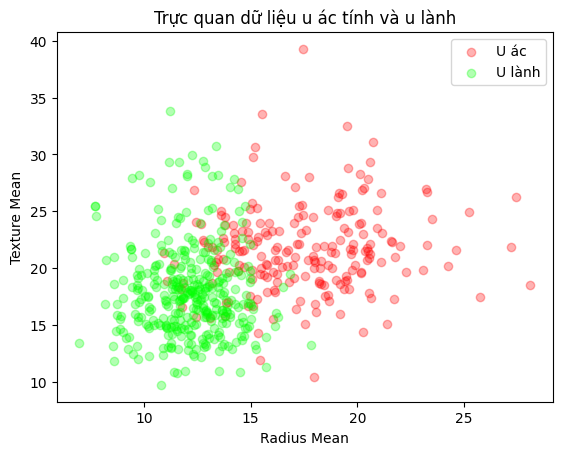

In [11]:
M = data[data['diagnosis'] == 1]
B = data[data['diagnosis'] == 0]

plt.title("Trực quan dữ liệu u ác tính và u lành")
plt.xlabel("Radius Mean")
plt.ylabel("Texture Mean")
plt.scatter(M.radius_mean, M.texture_mean, color = "red", label = "U ác", alpha = 0.3)
plt.scatter(B.radius_mean, B.texture_mean, color = "lime", label = "U lành",alpha = 0.3)
plt.legend()
plt.show()


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


feature = data['diagnosis']
X = data.drop('diagnosis', axis=1)

scaler.fit(X)

,copy,True
,with_mean,True
,with_std,True


In [15]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X, feature, test_size=0.2, random_state=42)

In [16]:
from sklearn.naive_bayes import MultinomialNB
model_MNB = MultinomialNB()
model_MNB.fit(X_train, y_train)
print("Multinormial Naive Bayes score: ", model_MNB.score(X_test, y_test))


Multinormial Naive Bayes score:  0.9385964912280702


In [17]:
# Gaussian Naive Bayes
from sklearn.naive_bayes import GaussianNB
model_GNB = GaussianNB()
model_GNB.fit(X_train, y_train)
print("Gaussian Naive Bayes score: ", model_GNB.score(X_test, y_test))

Gaussian Naive Bayes score:  0.9736842105263158


In [18]:
#predict the X_test[0]

print("Multinormial Naive Bayes predict: ", model_MNB.predict([X_test.iloc[0]]))
print("Gaussian Naive Bayes predict: ", model_GNB.predict([X_test.iloc[0]]))
print("Real label: ", y_test.iloc[0])

Multinormial Naive Bayes predict:  [0]
Gaussian Naive Bayes predict:  [0]
Real label:  0


c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MultinomialNB was fitted with feature names
  warnings.warn(
c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
